# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [8]:
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('data/banknote_authentication.csv' )

In [3]:
data.head()

,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


In [7]:
seed = 77678 

In [ ]:
train_data, test_data  = train_test_split(data,test_size=0.25, random_state=seed, stratify=data['counterfeit'])

In [14]:
feature_cols = ['a1', 'a2', 'a3']
X_train, y_train = train_data[feature_cols], train_data['counterfeit']
X_test,  y_test  = test_data[feature_cols],  test_data['counterfeit']

## Problem 

### A.

Perform the Quadratic Discriminant Analysis on this set. Calculate the confusion matrix, AUC score and plot the ROC curve. 

In [17]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

In [6]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [16]:
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X_train, y_train)

qda_proba_test = qda.predict_proba(X_test)[:, 1]
qda_proba_train = qda.predict_proba(X_train)[:, 1]

qda_pred_test  = qda.predict(X_test)
qda_pred_train  = qda.predict(X_train)

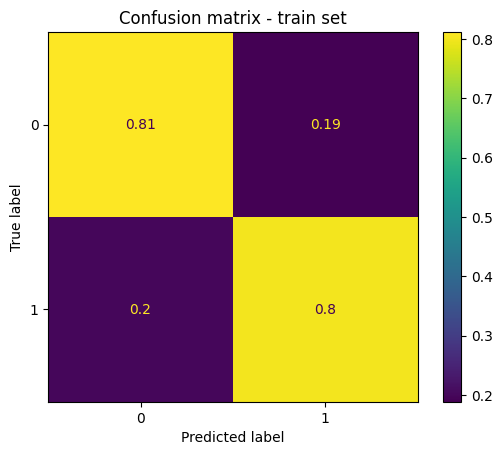

In [20]:
cm_qda_prob = confusion_matrix(y_train, qda_pred_train, normalize='true')
ConfusionMatrixDisplay(cm_qda_prob).plot()
plt.title('Confusion matrix - train set')
plt.show()

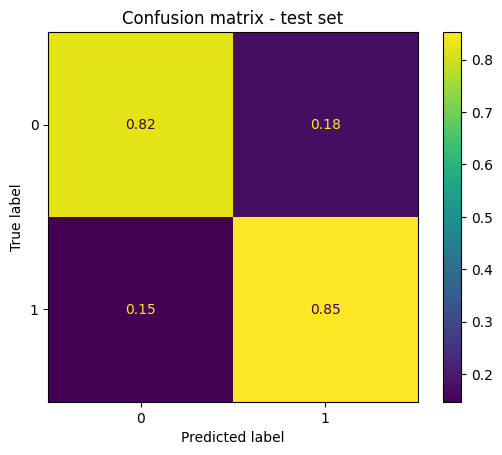

In [21]:
cm_qda_pred = confusion_matrix(y_test, qda_pred_test, normalize='true')
ConfusionMatrixDisplay(cm_qda_pred).plot()
plt.title('Confusion matrix - test set')
plt.show()

In [22]:
auc_train = roc_auc_score(y_train, qda_proba_train)
auc_test = roc_auc_score(y_test, qda_proba_test)

print(f'ROC AUC (train) = {auc_train:.4f}')
print(f'ROC AUC (test) = {auc_test:.4f}')

ROC AUC (train) = 0.8860
ROC AUC (test) = 0.9059


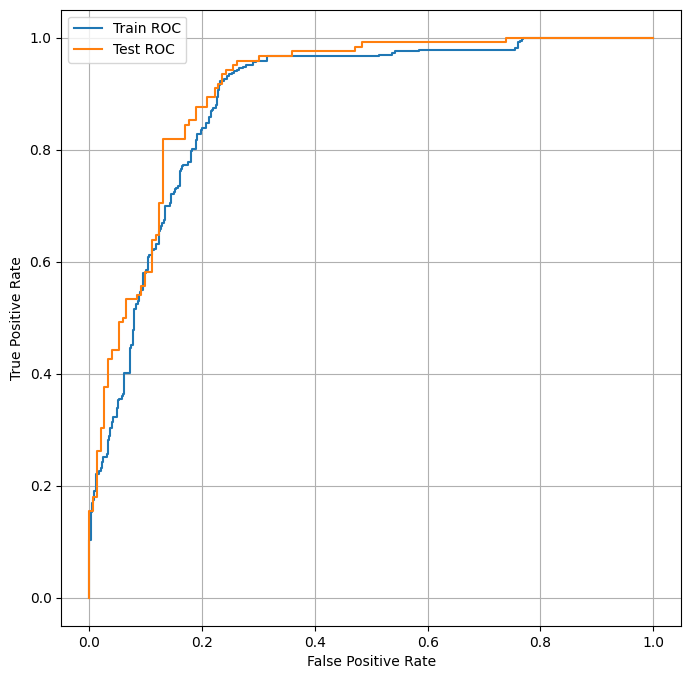

In [23]:
fprs_train, tprs_train, _ = roc_curve(y_train, qda_proba_train)
fprs_test, tprs_test, _ = roc_curve(y_test, qda_proba_test)

plt.figure(figsize=(8, 8))
plt.plot(fprs_train, tprs_train, label=f'Train ROC')
plt.plot(fprs_test, tprs_test, label=f'Test ROC')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

### B.

Perform Gaussian Mixture Discriminant Analysis on this set as described in the `gaussian_mixture_model_EM_algorithm` notebook. Use two components for positives and two components for negatives. Calculate the confusion matrix, AUC score and plot the ROC curve. 

In [24]:
from sklearn.mixture import GaussianMixture

In [27]:
def make_pdf(cmp):
    """
    Takes a GaussianMixture object and returns corresponding
    probability distribution function
    """
    n_cmp = cmp.n_components
    dists = [st.multivariate_normal(cmp.means_[i], cmp.covariances_[i]) for i in range(n_cmp)]
    def pdf(x):
        p = 0.0
        for i in range(n_cmp):
            p+= cmp.weights_[i]*dists[i].pdf(x)
        return p
    
    return pdf
    
    
def make_predict_proba(cmp0, cmp1, pi0=0.5, pi1=.5):
    """
    Takes two GaussianMixture object and corresponding priors and returns 
    pdf for conditional probability P(c=1|x)
    """
    pdf0 = make_pdf(cmp0)
    pdf1 = make_pdf(cmp1)
    def p(x):
        p0=pi0*pdf0(x)
        p1=pi1*pdf1(x)
        return p1/(p1+p0)    
        
    return p

In [26]:
gm0 = GaussianMixture(n_components=2, max_iter=200, tol=1e-4, random_state=0)
gm1 = GaussianMixture(n_components=2, max_iter=200, tol=1e-4, random_state=0)

gm0.fit(X_train[y_train == 0])
gm1.fit(X_train[y_train == 1])

,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.0001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",200
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0


In [30]:
mgda = make_predict_proba(gm0, gm1,pi1=0.445)
mgda_test_proba = mgda(X_test)
mgda_test_proba[:10]

array([1.71939728e-01, 9.35990127e-01, 9.99991010e-01, 9.99997707e-01,
       6.37022681e-04, 7.82548965e-01, 5.49918500e-03, 1.48121003e-01,
       9.94692299e-01, 8.28430485e-01])

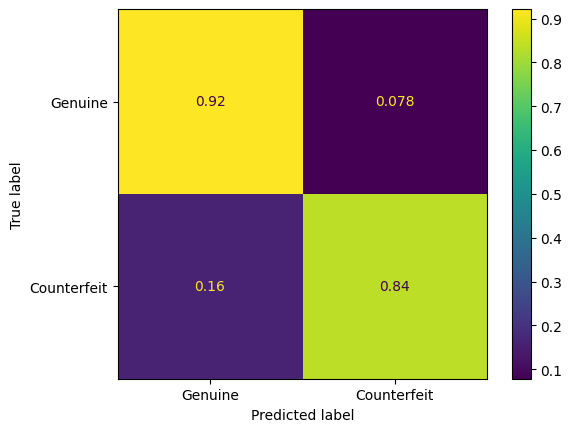

In [33]:
cm_gmda = confusion_matrix(y_test, mgda_test_proba > 0.5, normalize='true')
ConfusionMatrixDisplay(cm_gmda, display_labels=['Genuine', 'Counterfeit']).plot()
plt.show()

In [35]:
auc_gmda = roc_auc_score(y_test, mgda_test_proba)
fprs_gmda, tprs_gmda, _ = roc_curve(y_test, mgda_test_proba)

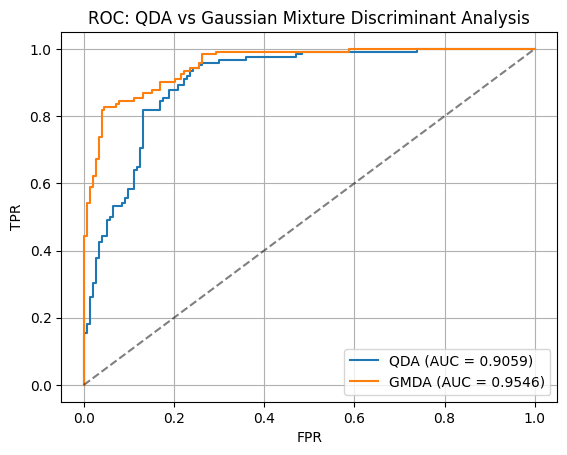

In [37]:
fig, ax = plt.subplots()
plt.plot(fprs_test, tprs_test, label=f"QDA (AUC = {auc_test:.4f})")
plt.plot(fprs_gmda, tprs_gmda, label=f"GMDA (AUC = {auc_gmda:.4f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC: QDA vs Gaussian Mixture Discriminant Analysis')
ax.grid(); ax.legend();